<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/pivoting_rod_bending.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Distribution of the internal shear force V(x) and bending moment M(x) along the length of the falling rod.

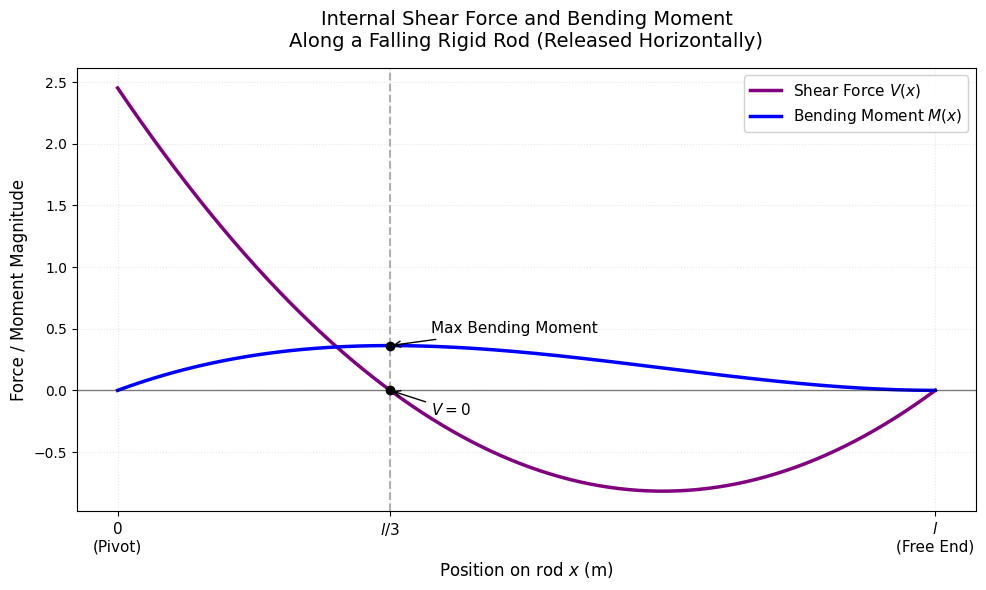

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_stresses(x, l=1.0, m=1.0, g=9.81, theta_deg=90):
    """
    Calculates the shear force V(x) and bending moment M(x)
    along a falling rigid rod.
    """
    theta_rad = np.radians(theta_deg)

    # Base multiplier: (mg sin(theta)) / (4l^2)
    multiplier = (m * g * np.sin(theta_rad)) / (4 * l**2)

    # Shear Force V(x)
    V = multiplier * (l - x) * (l - 3 * x)

    # Bending Moment M(x)
    M = multiplier * x * (l - x)**2

    return V, M

if __name__ == "__main__":
    # Set parameters for the rod
    l = 1.0  # length in meters
    x = np.linspace(0, l, 500)

    # Get values for a horizontal release (theta = 90 degrees)
    # This is when the bending stress is at its absolute maximum
    V, M = calculate_stresses(x, l=l, theta_deg=90)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot V(x) and M(x)
    # We scale V(x) slightly just for visual clarity on the same axis if needed,
    # but the native values show the intersection perfectly.
    ax.plot(x, V, 'purple', linewidth=2.5, label='Shear Force $V(x)$')
    ax.plot(x, M, 'blue', linewidth=2.5, label='Bending Moment $M(x)$')

    # Add markers for the critical point at x = l/3
    x_max_bend = l / 3
    V_at_max, M_max = calculate_stresses(x_max_bend, l=l)

    # Draw vertical reference line
    ax.axvline(x_max_bend, color='gray', linestyle='--', alpha=0.6)

    # Mark the max bending moment
    ax.plot(x_max_bend, M_max, 'ko', markersize=6, zorder=5)
    ax.annotate('Max Bending Moment', xy=(x_max_bend, M_max), xytext=(x_max_bend + 0.05, M_max + 0.1),
                arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=11)

    # Mark the zero-shear point
    ax.plot(x_max_bend, 0, 'ko', markersize=6, zorder=5)
    ax.annotate('$V=0$', xy=(x_max_bend, 0), xytext=(x_max_bend + 0.05, -0.2),
                arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=11)

    # Formatting and labels
    ax.set_title('Internal Shear Force and Bending Moment\nAlong a Falling Rigid Rod (Released Horizontally)', fontsize=14, pad=15)
    ax.set_xlabel('Position on rod $x$ (m)', fontsize=12)
    ax.set_ylabel('Force / Moment Magnitude', fontsize=12)

    # Custom x-ticks to show physical locations on the rod
    ax.set_xticks([0, l/3, l])
    ax.set_xticklabels(['$0$\n(Pivot)', '$l/3$', '$l$\n(Free End)'], fontsize=11)

    # Add zero-line and grid
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

    plt.tight_layout()
    plt.show()